# 01-3 Token 生 Token 之愚公移山

在 [上一节](./01-2-token_why_computable.ipynb) 中，我们搞清楚了 Token 如何变成可计算的向量。现在，最激动人心的部分来了：**模型如何从这些向量中"猜"出下一个 Token？**

大模型的生成过程就像愚公移山——一个 Token 一个 Token 地"搬"，每预测出一个就拼回去继续预测，直到生成完整的文本。

本节我们将：
1. 拆解从向量到下一个 Token 的完整流水线
2. 理解自回归生成：一个接一个地"吐"出文本
3. **深入采样过程**：模型到底是怎么从概率分布中"选"出下一个 Token 的？
4. **掌握推理参数**：如何控制生成的多样性与质量
5. **Qwen3.5 官方推荐参数解读**：为什么这样配？
6. 了解加速生成的秘密武器：KV Cache 与 MTP

In [12]:
from modelscope import AutoTokenizer, AutoModelForCausalLM
import torch
import torch.nn.functional as F
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import logging

logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("modelscope").setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

tokenizer_id = "Qwen/Qwen3.5-0.8B"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_id)

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
)
if os.environ.get('FORCE_CPU'):
    device = torch.device('cpu')
model = AutoModelForCausalLM.from_pretrained(tokenizer_id).to(device).eval()
print(f"模型加载完成: {tokenizer_id} (device: {device})")

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

模型加载完成: Qwen/Qwen3.5-0.8B (device: mps)


## 1. 变换：从 Token 到下一个 Token

现在我们有了 Token 的向量表示。接下来，这些向量要进入 **Transformer** 的层层变换，最终预测出下一个 Token。

整个流水线：

```
Token IDs → Embedding查表 → 24层Transformer Block → lm_head线性层 → Logits → Softmax概率 → 选出下一个Token
```

让我们用代码逐步拆解这个过程：

In [13]:
input_text = "你爱我，我爱你，蜜雪"
print(f"输入文本: '{input_text}'")

inputs = tokenizer(input_text, return_tensors="pt").to(device)
input_ids = inputs["input_ids"]
print(f"\n[Step 1] Token IDs: {input_ids.tolist()[0]}")

with torch.no_grad():
    embeddings = model.model.embed_tokens(input_ids)
print(f"[Step 2] Embedding 形状: {embeddings.shape} -> (batch_size, seq_len, hidden_size)")

with torch.no_grad():
    transformer_outputs = model.model(input_ids)
    hidden_states = transformer_outputs.last_hidden_state
print(f"[Step 3] 最后一层 Hidden States 形状: {hidden_states.shape}")

last_token_hidden_state = hidden_states[:, -1, :]
print(f"[Step 4] 用于预测的最后一个 Token 的向量形状: {last_token_hidden_state.shape}")

with torch.no_grad():
    logits = model.lm_head(last_token_hidden_state)
print(f"[Step 5] Logits 形状: {logits.shape} -> (batch_size, vocab_size={len(tokenizer)})")

probs = F.softmax(logits, dim=-1)
next_token_id = torch.argmax(probs, dim=-1).item()
next_token_str = tokenizer.decode([next_token_id])

print(f"\n=== 预测结果 ===")
print(f"最高概率的 Token ID: {next_token_id}")
print(f"对应的文本是: '{next_token_str}'")
print(f"拼接后的完整句子: '{input_text + next_token_str}'")

输入文本: '你爱我，我爱你，蜜雪'

[Step 1] Token IDs: [95933, 121196, 3709, 115734, 3709, 98735, 97055]
[Step 2] Embedding 形状: torch.Size([1, 7, 1024]) -> (batch_size, seq_len, hidden_size)
[Step 3] 最后一层 Hidden States 形状: torch.Size([1, 7, 1024])
[Step 4] 用于预测的最后一个 Token 的向量形状: torch.Size([1, 1024])
[Step 5] Logits 形状: torch.Size([1, 248320]) -> (batch_size, vocab_size=248077)

=== 预测结果 ===
最高概率的 Token ID: 97260
对应的文本是: '冰'
拼接后的完整句子: '你爱我，我爱你，蜜雪冰'


### 自回归生成：一个接一个地"吐"出文本

上面只预测了一个 Token。但大模型的真正工作方式是**自回归**的：每预测出一个 Token，就把它拼回输入，再预测下一个，如此循环。

让我们把"你爱我，我爱你，蜜雪"接下去补完：

In [14]:
generated_text = "你爱我，我爱你，蜜雪"
input_ids = tokenizer.encode(generated_text, return_tensors="pt").to(device)
max_new_tokens = 10

print(f"输入: '{generated_text}'")
print(f"\n--- 自回归生成过程 ---")

for step in range(max_new_tokens):
    with torch.no_grad():
        outputs = model.model(input_ids)
        last_hidden = outputs.last_hidden_state[:, -1, :]
        logits = model.lm_head(last_hidden)
        probs = F.softmax(logits, dim=-1)
        next_id = torch.argmax(probs, dim=-1).item()
    
    next_str = tokenizer.decode([next_id])
    generated_text += next_str
    input_ids = torch.cat([input_ids, torch.tensor([[next_id]], device=device)], dim=1)
    
    print(f"  Step {step+1:>2d}: 预测 Token '{next_str}' (ID={next_id})  ->  当前文本: '{generated_text}'")
    
    if next_id == tokenizer.eos_token_id:
        print(f"  ✔ 生成结束符出现，停止生成。")
        break

print(f"\n=== 最终结果 ===")
print(f"'{generated_text}'")

输入: '你爱我，我爱你，蜜雪'

--- 自回归生成过程 ---
  Step  1: 预测 Token '冰' (ID=97260)  ->  当前文本: '你爱我，我爱你，蜜雪冰'
  Step  2: 预测 Token '城' (ID=96191)  ->  当前文本: '你爱我，我爱你，蜜雪冰城'
  Step  3: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，'
  Step  4: 预测 Token '你' (ID=95933)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你'
  Step  5: 预测 Token '爱我' (ID=121196)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我'
  Step  6: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，'
  Step  7: 预测 Token '我爱你' (ID=115734)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你'
  Step  8: 预测 Token '，' (ID=3709)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，'
  Step  9: 预测 Token '蜜' (ID=98735)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜'
  Step 10: 预测 Token '雪' (ID=97055)  ->  当前文本: '你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪'

=== 最终结果 ===
'你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪'


---

## 2. 采样：模型到底是怎么"选"出下一个 Token 的？

上面的自回归生成中，我们始终用 `argmax` 选概率最高的 Token——这叫**贪心解码**。但实际使用大模型时，输出并不是确定性的：同样的 prompt，每次可能得到不同的回答。

**关键问题：模型到底是怎么从概率分布中"选"出下一个 Token 的？答案是——加权随机抽样。**

让我们一步步拆解这个完整过程：

```
模型输出 Logits (原始分数)
    ↓
[1] Penalty 修改 Logits (惩罚已出现的 Token)
    ↓
[2] Temperature 缩放 Logits (控制分布尖锐程度)
    ↓
[3] Softmax 转为概率分布
    ↓
[4] Top-k / Top-p / Min-p 过滤 (去掉不合理的候选)
    ↓
[5] 重新归一化
    ↓
[6] 加权随机抽样 (概率越高的 Token 越容易被选中，但不是100%)
    ↓
下一个 Token
```

**核心区别**：贪心解码 = 永远选概率最高的；采样 = 按概率随机抽，概率高的更可能被选中，但低概率的也有机会。

### 2.1 第一步：从 Logits 到概率分布

模型最后一层输出的是 **Logits**（原始分数），可以是任意实数。通过 **Softmax** 将其转为概率分布（所有概率之和 = 1）：

$$P(token_i) = \frac{e^{logit_i}}{\sum_j e^{logit_j}}$$

概率最高的 Token 不一定被选中——它只是被选中的**可能性最大**。

In [15]:
input_text = "你爱我，我爱你，蜜雪"
input_ids_tok = tokenizer.encode(input_text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.model(input_ids_tok)
    raw_logits = model.lm_head(outputs.last_hidden_state[:, -1, :])

probs = F.softmax(raw_logits, dim=-1)[0]
top_probs, top_ids = torch.topk(probs, 10)
top_tokens = [tokenizer.decode([tid.item()]) for tid in top_ids]

print("=== Softmax 后的概率分布 (Top-10) ===")
print(f"{'Token':<8s} {'概率':<12s} {'可视化'}")
print("-" * 60)
for tok, p in zip(top_tokens, top_probs.tolist()):
    bar = "█" * int(p * 200)
    print(f"{tok:<8s} {p:<12.4%} {bar}")

print(f"\n所有 Token 概率之和: {probs.sum().item():.6f}")
print(f"Top-10 累积概率: {top_probs.sum().item():.4%}")
print(f"剩余 {len(tokenizer)-10} 个 Token 共享: {(1-top_probs.sum().item()):.4%} 的概率")

=== Softmax 后的概率分布 (Top-10) ===
Token    概率           可视化
------------------------------------------------------------
冰        74.2188%     ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
儿        14.6484%     █████████████████████████████
卡        1.2756%      ██
天        0.7751%      █
龙        0.4425%      
甘        0.3433%      
莱        0.3235%      
柠檬       0.3036%      

        0.2518%      


       0.1839%      

所有 Token 概率之和: 1.000000
Top-10 累积概率: 92.5781%
剩余 248067 个 Token 共享: 7.4219% 的概率


### 2.2 第二步：加权随机抽样——概率就是"权重"

有了概率分布后，**采样**就是按概率做加权随机抽取——就像一个加权轮盘赌：

- 概率 73% 的 Token → 被抽中的机会是 73%（但不是 100%！）
- 概率 14% 的 Token → 被抽中的机会是 14%
- 概率 0.01% 的 Token → 被抽中的机会极小，但不是零

这就是为什么同样的 prompt 可以生成不同的回答！

In [16]:
torch.manual_seed(42)
n_samples = 10000

sampled_ids = torch.multinomial(probs.cpu(), num_samples=n_samples, replacement=True)
sampled_counter = {}
for sid in sampled_ids.tolist():
    tok = tokenizer.decode([sid])
    sampled_counter[tok] = sampled_counter.get(tok, 0) + 1

top10_sampled = sorted(sampled_counter.items(), key=lambda x: -x[1])[:10]

print(f"=== 采样 {n_samples} 次的统计 vs 理论概率 ===")
print(f"{'Token':<8s} {'采样次数':<10s} {'采样频率':<12s} {'理论概率':<12s} {'偏差'}")
print("-" * 65)
for tok, count in top10_sampled:
    freq = count / n_samples
    tid = tokenizer.encode(tok)[0]
    theory = probs[tid].item()
    diff = freq - theory
    print(f"{tok:<8s} {count:<10d} {freq:<12.4%} {theory:<12.4%} {diff:+.4%}")

print(f"\n💡 观察: 采样频率 ≈ 理论概率，但每次单次采样的结果是不确定的！")
print(f"   这就是大模型'创造性'的来源——不是每次都选最高概率的 Token。")

=== 采样 10000 次的统计 vs 理论概率 ===
Token    采样次数       采样频率         理论概率         偏差
-----------------------------------------------------------------
冰        7448       74.4800%     74.2188%     +0.2613%
儿        1456       14.5600%     14.6484%     -0.0884%
卡        149        1.4900%      1.2756%      +0.2144%
天        82         0.8200%      0.7751%      +0.0449%
甘        35         0.3500%      0.3433%      +0.0067%
龙        35         0.3500%      0.4425%      -0.0925%
莱        32         0.3200%      0.3235%      -0.0035%

        22         0.2200%      0.2518%      -0.0318%
柠檬       21         0.2100%      0.3036%      -0.0936%
巴        19         0.1900%      0.1625%      +0.0275%

💡 观察: 采样频率 ≈ 理论概率，但每次单次采样的结果是不确定的！
   这就是大模型'创造性'的来源——不是每次都选最高概率的 Token。


### 2.3 Temperature：控制概率分布的"尖锐程度"

**Temperature** 通过缩放 logits 来改变概率分布的形状：

- **Temperature < 1**：概率分布更尖锐 → 高概率 Token 更突出 → 采样时更倾向选最高概率的
- **Temperature = 1**：原始概率分布
- **Temperature > 1**：概率分布更平坦 → 低概率 Token 也有机会 → 采样结果更多样
- **Temperature → 0**：几乎等价于贪心解码

数学原理：`softmax(logits / temperature)`

> 注意：Temperature 不改变候选 Token 的集合，只改变它们被选中的概率。

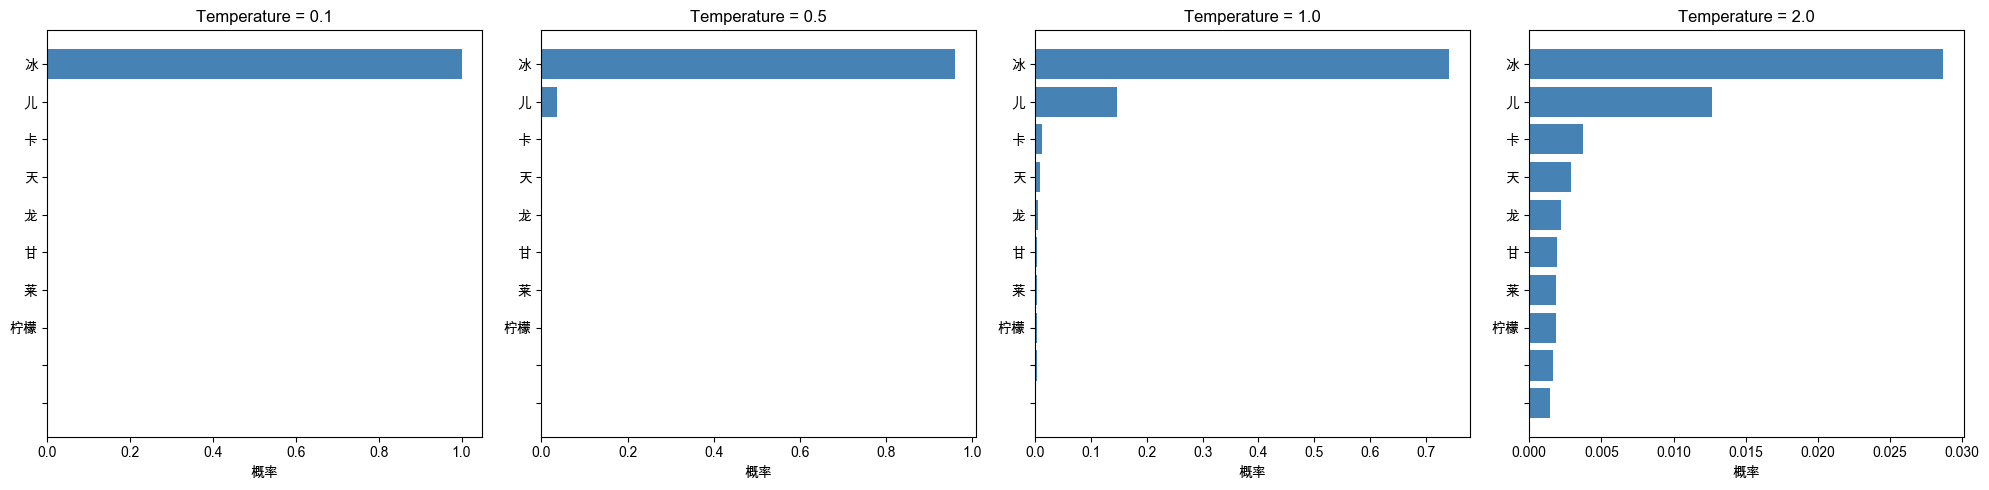

💡 观察:
  - Temperature=0.1: 几乎100%概率集中在'冰'上，采样几乎必定选它（等价贪心）
  - Temperature=1.0: 原始分布，'冰'约73%，其他Token也有机会
  - Temperature=2.0: 概率被'摊平'，低概率Token被选中的机会大增


In [17]:
temperatures = [0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 5))

for ax, temp in zip(axes, temperatures):
    scaled_logits = raw_logits / temp
    probs_t = F.softmax(scaled_logits, dim=-1)
    top_probs_t, top_ids_t = torch.topk(probs_t[0], 10)
    top_tokens_t = [tokenizer.decode([tid.item()]) for tid in top_ids_t]
    
    ax.barh(range(10), top_probs_t.tolist(), color='steelblue')
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_tokens_t)
    ax.set_xlabel('概率')
    ax.set_title(f'Temperature = {temp}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("💡 观察:")
print("  - Temperature=0.1: 几乎100%概率集中在'冰'上，采样几乎必定选它（等价贪心）")
print("  - Temperature=1.0: 原始分布，'冰'约73%，其他Token也有机会")
print("  - Temperature=2.0: 概率被'摊平'，低概率Token被选中的机会大增")

### 2.4 Top-k、Top-p、Min-p：过滤不合理的候选

即使调了 Temperature，词表中仍有几十万个 Token，其中大部分概率极低。以下三种策略用于**过滤掉不合理的候选**，让采样只在"靠谱"的 Token 中进行：

| 参数 | 策略 | 特点 |
| --- | --- | --- |
| **Top-k** | 只保留概率最高的 k 个 Token | 简单粗暴，但 k 值难以选择 |
| **Top-p (Nucleus Sampling)** | 保留累积概率达到 p 的最小 Token 集合 | 动态调整候选数量 |
| **Min-p** | 只保留概率 >= 最大概率 x min_p 的 Token | 相对阈值，自动适应分布形状 |

**关键理解**：这些参数不改变采样方式（仍然是加权随机），只是**缩小了采样的候选池**。被过滤掉的 Token 概率被设为 0，剩余 Token 的概率重新归一化后，再做加权随机抽样。

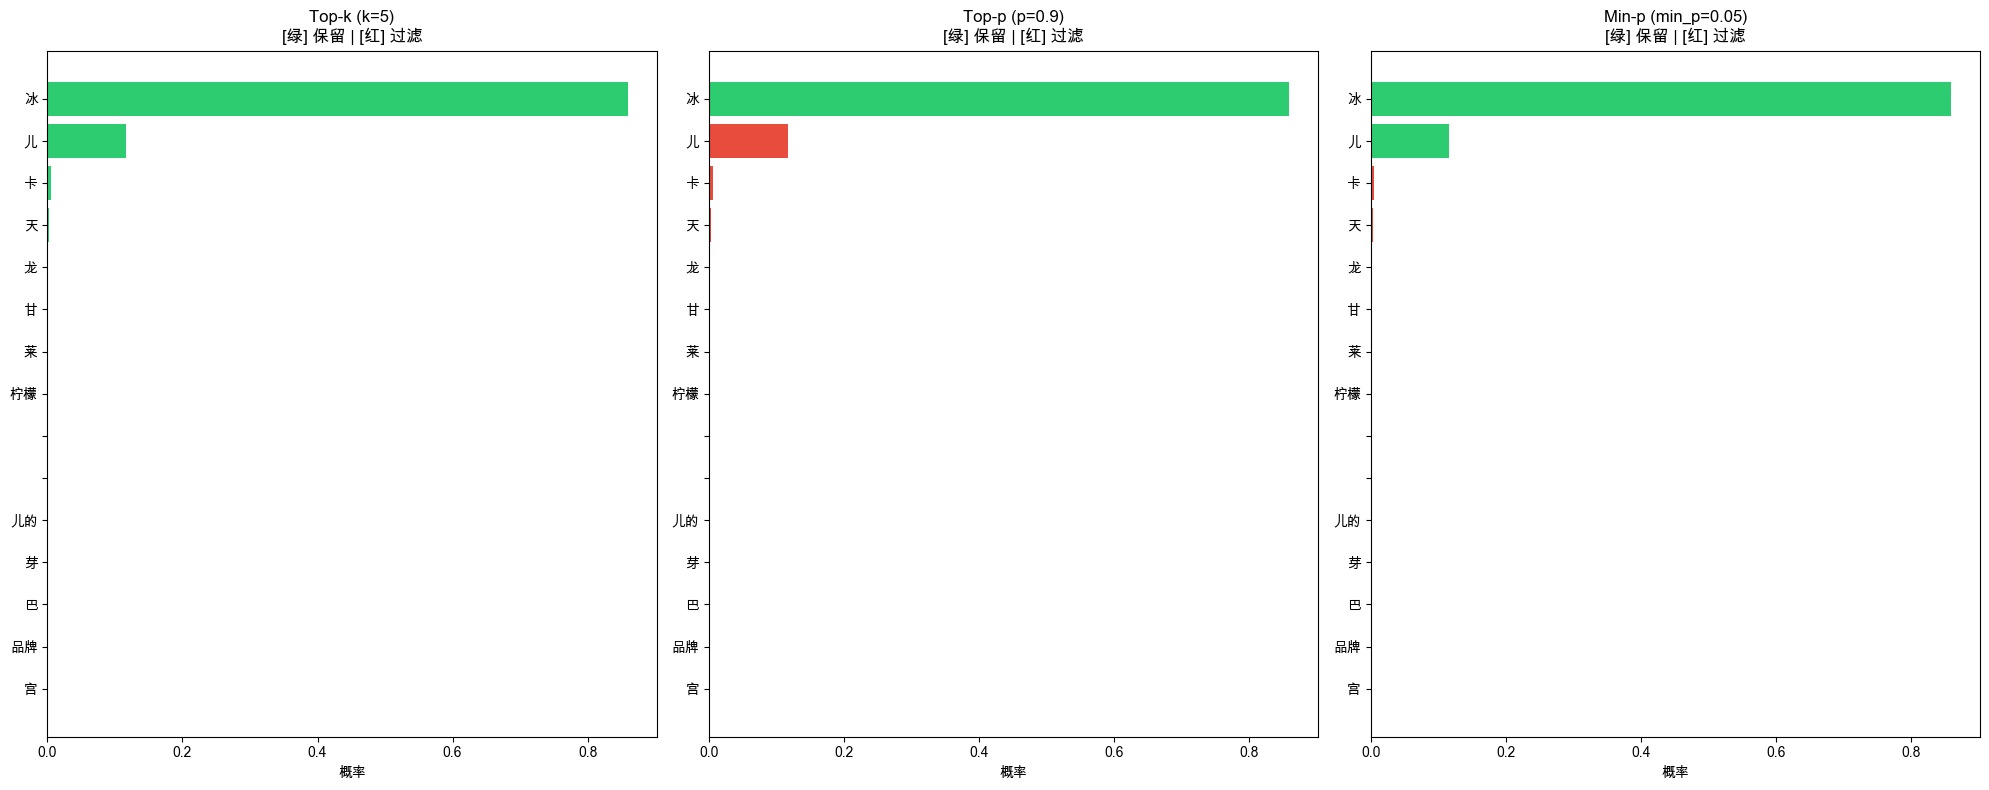

💡 观察:
  - Top-k=5: 固定保留概率最高的 5 个候选
  - Top-p=0.9: 保留累积概率达到 0.9 的最小集合（动态数量）
  - Min-p=0.05: 只保留概率 >= 最大概率x0.05 = 0.0430 的 Token


In [18]:
with torch.no_grad():
    outputs = model.model(input_ids_tok)
    logits_for_filter = model.lm_head(outputs.last_hidden_state[:, -1, :])
    base_probs = F.softmax(logits_for_filter / 0.8, dim=-1)[0]

sorted_probs, sorted_ids = torch.sort(base_probs, descending=True)
sorted_tokens = [tokenizer.decode([tid.item()]) for tid in sorted_ids[:20]]
cumulative_probs = torch.cumsum(sorted_probs, dim=0)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

top_n = 15

top_k = 5
colors_k = ['#2ecc71' if i < top_k else '#e74c3c' for i in range(top_n)]
axes[0].barh(range(top_n), sorted_probs[:top_n].tolist(), color=colors_k)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(sorted_tokens[:top_n])
axes[0].set_xlabel('概率')
axes[0].set_title(f'Top-k (k={top_k})\n[绿] 保留 | [红] 过滤')
axes[0].invert_yaxis()

top_p = 0.9
cutoff_idx = (cumulative_probs[:top_n] < top_p).sum().item()
colors_p = ['#2ecc71' if i < cutoff_idx else '#e74c3c' for i in range(top_n)]
axes[1].barh(range(top_n), sorted_probs[:top_n].tolist(), color=colors_p)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(sorted_tokens[:top_n])
axes[1].set_xlabel('概率')
axes[1].set_title(f'Top-p (p={top_p})\n[绿] 保留 | [红] 过滤')
axes[1].invert_yaxis()

min_p = 0.05
threshold = sorted_probs[0].item() * min_p
colors_m = ['#2ecc71' if sorted_probs[i].item() >= threshold else '#e74c3c' for i in range(top_n)]
axes[2].barh(range(top_n), sorted_probs[:top_n].tolist(), color=colors_m)
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels(sorted_tokens[:top_n])
axes[2].set_xlabel('概率')
axes[2].set_title(f'Min-p (min_p={min_p})\n[绿] 保留 | [红] 过滤')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("💡 观察:")
print(f"  - Top-k={top_k}: 固定保留概率最高的 {top_k} 个候选")
print(f"  - Top-p={top_p}: 保留累积概率达到 {top_p} 的最小集合（动态数量）")
print(f"  - Min-p={min_p}: 只保留概率 >= 最大概率x{min_p} = {threshold:.4f} 的 Token")

### 2.5 Presence Penalty 与 Repetition Penalty：减少重复

上面的参数控制"怎么选"，而 **Penalty** 类参数控制"选过的别再选"：

- **Repetition Penalty**：对已出现过的 Token，将其 logits 除以惩罚值（>1 降权）。正 logits 被除以 penalty，负 logits 被乘以 penalty
- **Presence Penalty**：对已出现过的 Token，直接从 logits 中减去一个固定值。只要出现过就惩罚，不管出现了几次——鼓励模型"聊点新的"

| 参数 | 作用方式 | 效果 |
| --- | --- | --- |
| **repetition_penalty** | logits 除以/乘以惩罚值 | 降低已出现 Token 的概率，值越大越不容易重复 |
| **presence_penalty** | logits 减去固定值 | 鼓励出现新 Token，增加话题多样性 |

### 2.6 完整采样流程演示

让我们用代码模拟一次完整的采样过程，从 Logits 到最终选出的 Token：

In [19]:
def sample_next_token(input_text, temperature=1.0, top_k=None, top_p=None, min_p_val=None,
                      presence_penalty=0.0, repetition_penalty=1.0, seed=None, verbose=True):
    if seed is not None:
        torch.manual_seed(seed)
    
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    generated_tokens = input_ids[0].tolist()
    
    with torch.no_grad():
        outputs = model.model(input_ids)
        logits = model.lm_head(outputs.last_hidden_state[:, -1, :]).clone()
    
    if verbose:
        top5_raw_probs = F.softmax(logits, dim=-1)[0]
        top5_v, top5_i = torch.topk(top5_raw_probs, 5)
        top5_t = [tokenizer.decode([tid.item()]) for tid in top5_i]
        print(f"[原始 Logits -> Softmax] Top-5: {list(zip(top5_t, [f'{p:.2%}' for p in top5_v.tolist()]))}")
    
    if repetition_penalty != 1.0:
        for tid in set(generated_tokens):
            if logits[0, tid] > 0:
                logits[0, tid] /= repetition_penalty
            else:
                logits[0, tid] *= repetition_penalty
        if verbose:
            print(f"[Repetition Penalty={repetition_penalty}] 已对 {len(set(generated_tokens))} 个已出现 Token 降权")
    
    if presence_penalty != 0.0:
        for tid in set(generated_tokens):
            logits[0, tid] -= presence_penalty
        if verbose:
            print(f"[Presence Penalty={presence_penalty}] 已对 {len(set(generated_tokens))} 个已出现 Token 减分")
    
    if temperature != 1.0:
        logits = logits / temperature
        if verbose:
            print(f"[Temperature={temperature}] Logits 已缩放")
    
    probs = F.softmax(logits, dim=-1)[0]
    
    if min_p_val is not None:
        threshold = probs.max() * min_p_val
        mask = probs < threshold
        probs[mask] = 0.0
        if verbose:
            kept = (mask == False).sum().item()
            print(f"[Min-p={min_p_val}] 阈值={threshold:.6f}, 保留 {kept} 个候选")
    
    if top_k is not None:
        top_k_values, _ = torch.topk(probs, min(top_k, probs.size(-1)))
        probs[probs < top_k_values[-1]] = 0.0
        if verbose:
            kept = (probs > 0).sum().item()
            print(f"[Top-k={top_k}] 保留 {kept} 个候选")
    
    if top_p is not None:
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)
        cumulative_probs = torch.cumsum(sorted_probs, dim=0)
        sorted_mask = cumulative_probs - sorted_probs > top_p
        sorted_probs[sorted_mask] = 0.0
        probs.scatter_(0, sorted_indices, sorted_probs)
        if verbose:
            kept = (probs > 0).sum().item()
            print(f"[Top-p={top_p}] 保留 {kept} 个候选")
    
    probs = probs / probs.sum()
    if verbose:
        top5_final_v, top5_final_i = torch.topk(probs, 5)
        top5_final_t = [tokenizer.decode([tid.item()]) for tid in top5_final_i]
        print(f"[重新归一化后] Top-5: {list(zip(top5_final_t, [f'{p:.2%}' for p in top5_final_v.tolist()]))}")
    
    next_id = torch.multinomial(probs.cpu(), num_samples=1).item()
    next_token = tokenizer.decode([next_id])
    prob_of_chosen = probs[next_id].item()
    
    if verbose:
        print(f"\n>>> 加权随机抽样结果: '{next_token}' (被选中概率={prob_of_chosen:.2%})")
    
    return next_id, next_token

print("=" * 70)
print("演示1: 贪心解码 (temperature→0)")
print("=" * 70)
sample_next_token("你爱我，我爱你，蜜雪", temperature=0.01, seed=42)

print(f"\n{'=' * 70}")
print("演示2: 采样解码 (temperature=0.8, top_p=0.9)")
print("=" * 70)
sample_next_token("你爱我，我爱你，蜜雪", temperature=0.8, top_p=0.9, seed=42)

print(f"\n{'=' * 70}")
print("演示3: 高温度采样 (temperature=1.5)")
print("=" * 70)
sample_next_token("你爱我，我爱你，蜜雪", temperature=1.5, seed=42)

演示1: 贪心解码 (temperature→0)
[原始 Logits -> Softmax] Top-5: [('冰', '74.22%'), ('儿', '14.65%'), ('卡', '1.28%'), ('天', '0.78%'), ('龙', '0.44%')]
[Temperature=0.01] Logits 已缩放
[重新归一化后] Top-5: [('冰', '100.00%'), ('!', '0.00%'), ('"', '0.00%'), ('#', '0.00%'), ('$', '0.00%')]

>>> 加权随机抽样结果: '冰' (被选中概率=100.00%)

演示2: 采样解码 (temperature=0.8, top_p=0.9)
[原始 Logits -> Softmax] Top-5: [('冰', '74.22%'), ('儿', '14.65%'), ('卡', '1.28%'), ('天', '0.78%'), ('龙', '0.44%')]
[Temperature=0.8] Logits 已缩放
[Top-p=0.9] 保留 2 个候选
[重新归一化后] Top-5: [('冰', '87.89%'), ('儿', '11.91%'), ('!', '0.00%'), ('"', '0.00%'), ('#', '0.00%')]

>>> 加权随机抽样结果: '儿' (被选中概率=11.91%)

演示3: 高温度采样 (temperature=1.5)
[原始 Logits -> Softmax] Top-5: [('冰', '74.22%'), ('儿', '14.65%'), ('卡', '1.28%'), ('天', '0.78%'), ('龙', '0.44%')]
[Temperature=1.5] Logits 已缩放
[重新归一化后] Top-5: [('冰', '21.09%'), ('儿', '6.84%'), ('卡', '1.35%'), ('天', '0.98%'), ('龙', '0.68%')]

>>> 加权随机抽样结果: '儿' (被选中概率=6.84%)


(96408, '儿')

### 2.7 生成效果对比

让我们用不同的参数组合来生成文本，直观感受各参数的影响：

In [20]:
def generate_with_params(input_text, temperature=1.0, top_k=None, top_p=None, min_p_val=None,
                         presence_penalty=0.0, repetition_penalty=1.0, max_new_tokens=15, seed=42):
    torch.manual_seed(seed)
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    generated_tokens = input_ids[0].tolist()
    past_kv = None
    
    for step in range(max_new_tokens):
        with torch.no_grad():
            if past_kv is None:
                outputs = model.model(torch.tensor([generated_tokens], device=device), use_cache=True)
            else:
                outputs = model.model(torch.tensor([[generated_tokens[-1]]], device=device), past_key_values=past_kv, use_cache=True)
            past_kv = outputs.past_key_values
            logits = model.lm_head(outputs.last_hidden_state[:, -1, :]).clone()
        
        if repetition_penalty != 1.0:
            for tid in set(generated_tokens):
                if logits[0, tid] > 0:
                    logits[0, tid] /= repetition_penalty
                else:
                    logits[0, tid] *= repetition_penalty
        
        if presence_penalty != 0.0:
            for tid in set(generated_tokens):
                logits[0, tid] -= presence_penalty
        
        if temperature != 1.0:
            logits = logits / temperature
        
        probs = F.softmax(logits, dim=-1)[0]
        
        if min_p_val is not None:
            threshold = probs.max() * min_p_val
            probs[probs < threshold] = 0.0
        
        if top_k is not None:
            top_k_values, _ = torch.topk(probs, min(top_k, probs.size(-1)))
            probs[probs < top_k_values[-1]] = 0.0
        
        if top_p is not None:
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=0)
            sorted_mask = cumulative_probs - sorted_probs > top_p
            sorted_probs[sorted_mask] = 0.0
            probs.scatter_(0, sorted_indices, sorted_probs)
        
        if probs.sum() > 0:
            probs = probs / probs.sum()
        
        next_id = torch.multinomial(probs.cpu(), num_samples=1).item()
        generated_tokens.append(next_id)
        
        if next_id == tokenizer.eos_token_id:
            break
    
    return tokenizer.decode(generated_tokens)

input_text = "你爱我，我爱你，蜜雪"
configs = [
    ("贪心解码 (temperature→0)", {"temperature": 0.01}),
    ("低温度 (temperature=0.3)", {"temperature": 0.3}),
    ("高温度 (temperature=1.5)", {"temperature": 1.5}),
    ("Top-p=0.9", {"temperature": 0.8, "top_p": 0.9}),
    ("Min-p=0.05", {"temperature": 0.8, "min_p_val": 0.05}),
]

for label, params in configs:
    result = generate_with_params(input_text, max_new_tokens=15, **params)
    print(f"[{label}]")
    print(f"  {result}")
    print()

[贪心解码 (temperature→0)]
  你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰城，你爱我

[低温度 (temperature=0.3)]
  你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪冰城。你爱我

[高温度 (temperature=1.5)]
  你爱我，我爱你，蜜雪儿！1 辆车 выпла还江出喝呢uai。 Sheuture

[Top-p=0.9]
  你爱我，我爱你，蜜雪儿！

好棒！

<think>

</think>

收到！�

[Min-p=0.05]
  你爱我，我爱你，蜜雪儿！

<think>
Here's a thinking process that leads to the suggested



---

## 3. Qwen3.5 官方推荐参数解读

Qwen3.5 官方给出了不同场景的推荐参数组合：

| 场景 | temperature | top_p | top_k | min_p | presence_penalty | repetition_penalty |
| --- | --- | --- | --- | --- | --- | --- |
| 通用任务（思考模式） | 1.0 | 0.95 | 20 | 0.0 | 1.5 | 1.0 |
| 精确编码（思考模式） | 0.6 | 0.95 | 20 | 0.0 | 0.0 | 1.0 |
| 通用任务（非思考模式） | 0.7 | 0.8 | 20 | 0.0 | 1.5 | 1.0 |
| 推理任务（非思考模式） | 1.0 | 0.95 | 20 | 0.0 | 1.5 | 1.0 |

让我们逐个解读这些参数背后的逻辑：

### 为什么思考模式 temperature=1.0，而非思考模式 temperature=0.7？

- **思考模式**（即模型先在 `<think＞...</think＞` 中"内心独白"再输出答案）：思考过程需要模型自由探索推理路径，temperature=1.0 保持原始概率分布，让模型在推理时能"想到"更多可能性
- **非思考模式**（直接输出答案）：用户期望更确定、更聚焦的回答，temperature=0.7 让分布更尖锐，减少"跑偏"

### 为什么编码任务 temperature=0.6 且 presence_penalty=0.0？

- 代码需要**精确性**，低 temperature 让模型更倾向选最高概率的 Token（代码语法几乎没"创造性"空间）
- presence_penalty=0.0 因为代码中**变量名、关键字需要重复出现**，惩罚重复反而会破坏代码结构

### 为什么通用任务 presence_penalty=1.5？

- 通用对话中，模型容易陷入重复循环（如反复说"是的"、"没错"），presence_penalty=1.5 鼓励模型"聊点新的"
- 注意：presence_penalty 只关心 Token **是否出现过**，不关心出现次数，所以不会过度惩罚合理的重复

### 为什么 top_k=20 且 top_p=0.95？

- top_k=20 作为"安全网"，确保不会选到太离谱的 Token
- top_p=0.95 在大多数情况下已经覆盖了合理的候选范围
- 两者同时生效时，取交集，进一步缩小候选池

### 为什么 min_p=0.0？

- top_k + top_p 的组合已经足够有效，min_p 作为额外的过滤层在此场景下不需要
- min_p 更适合某些需要更精细控制的场景（如创意写作中避免"太安全"的输出）

### 参数速查表

| 参数 | 典型范围 | 作用 | 建议值 |
| --- | --- | --- | --- |
| **temperature** | 0 ~ 2 | 控制随机性 | 代码/事实: 0~0.3, 创意: 0.7~1.2 |
| **top_k** | 1 ~ 100 | 限制候选数量 | 20~50 |
| **top_p** | 0.1 ~ 1.0 | 累积概率阈值 | 0.9~0.95 |
| **min_p** | 0.01 ~ 0.2 | 相对概率阈值 | 0.05~0.1 |
| **presence_penalty** | 0 ~ 2 | 鼓励新话题 | 0~1.5 |
| **repetition_penalty** | 1.0 ~ 2.0 | 减少重复 | 1.0~1.2 |

> 💡 实际使用中，最常用的组合是 `temperature + top_p + top_k`，Penalty 类参数在需要长文本生成时特别有用。

---

## 4. 加速生成的秘密武器

### 4.1 KV Cache：避免重复计算

在自回归生成中，我们每预测一个新 Token，都要把**整个序列**重新送入模型计算。这显然很浪费！因为之前 Token 的 Key 和 Value 向量已经算过了。

**KV Cache（键值缓存）** 的核心思想：**把每一层 Self-Attention 计算出的 Key 和 Value 向量缓存下来，下次只需要计算新 Token 的 Query，然后和缓存的 K、V 做注意力计算即可。**

```
无 KV Cache:  每一步都重新计算所有 Token 的 K、V
  Step 1: [T1]           → 计算 K1, V1
  Step 2: [T1, T2]       → 重新计算 K1, V1, K2, V2
  Step 3: [T1, T2, T3]   → 重新计算 K1, V1, K2, V2, K3, V3
  ...

有 KV Cache:  只计算新 Token 的 K、V，复用缓存的
  Step 1: [T1]           → 计算 K1, V1，缓存
  Step 2: [T2]           → 只计算 K2, V2，复用 K1, V1
  Step 3: [T3]           → 只计算 K3, V3，复用 K1-K2, V1-V2
  ...
```

这使得每一步的计算量从 O(seq_len²) 降低到 O(seq_len)，在长文本生成时加速效果非常显著。

> 📖 参考: [HuggingFace KV Cache 官方文档](https://huggingface.co/docs/transformers/v5.8.1/en/kv_cache)

In [21]:
import time

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
)
print(f"Using device: {device}")

model = model.to(device)

input_text = "你爱我，我爱你，蜜雪"
inputs = tokenizer(input_text, return_tensors="pt").to(device)
input_ids = inputs["input_ids"]
max_new_tokens = 10

print("[无 KV Cache] 自回归生成...")
start = time.time()
generated_ids_no_cache = input_ids.clone()
for step in range(max_new_tokens):
    with torch.no_grad():
        outputs = model.model(generated_ids_no_cache, use_cache=False)
        last_hidden = outputs.last_hidden_state[:, -1, :]
        logits = model.lm_head(last_hidden)
        next_id = torch.argmax(logits, dim=-1).unsqueeze(0)
    generated_ids_no_cache = torch.cat([generated_ids_no_cache, next_id], dim=1)
no_cache_time = time.time() - start
result_no_cache = tokenizer.decode(generated_ids_no_cache[0])
print(f"  结果: {result_no_cache}")
print(f"  耗时: {no_cache_time:.3f}s")

print(f"\n[有 KV Cache] 自回归生成...")
start = time.time()
generated_ids_cache = input_ids.clone()
past_key_values = None
for step in range(max_new_tokens):
    with torch.no_grad():
        if past_key_values is None:
            outputs = model.model(generated_ids_cache, past_key_values=past_key_values, use_cache=True)
        else:
            next_input = generated_ids_cache[:, -1:]
            outputs = model.model(next_input, past_key_values=past_key_values, use_cache=True)
        past_key_values = outputs.past_key_values
        last_hidden = outputs.last_hidden_state[:, -1, :]
        logits = model.lm_head(last_hidden)
        next_id = torch.argmax(logits, dim=-1).unsqueeze(0)
    generated_ids_cache = torch.cat([generated_ids_cache, next_id], dim=1)
cache_time = time.time() - start
result_cache = tokenizer.decode(generated_ids_cache[0])
print(f"  结果: {result_cache}")
print(f"  耗时: {cache_time:.3f}s")

print(f"\n=== 对比 ===")
print(f"  无 KV Cache: {no_cache_time:.3f}s")
print(f"  有 KV Cache: {cache_time:.3f}s")
if cache_time > 0:
    print(f"  加速比: {no_cache_time/cache_time:.1f}x")
print(f"  结果一致: {result_no_cache == result_cache}")

Using device: mps
[无 KV Cache] 自回归生成...
  结果: 你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪
  耗时: 0.736s

[有 KV Cache] 自回归生成...
  结果: 你爱我，我爱你，蜜雪冰城，你爱我，我爱你，蜜雪
  耗时: 0.234s

=== 对比 ===
  无 KV Cache: 0.736s
  有 KV Cache: 0.234s
  加速比: 3.2x
  结果一致: True


### KV Cache 的代价与优化

KV Cache 虽然加速了生成，但也有代价：**显存占用**。每缓存一个 Token 的 K、V 向量，需要消耗 `2 × 层数 × 隐藏维度` 的存储空间。

对于长文本生成（如 100K Token 的上下文），KV Cache 可能占用数 GB 甚至数十 GB 的显存。
因此，HuggingFace Transformers 提供了多种 Cache 优化策略（参考 [官方文档](https://huggingface.co/docs/transformers/v5.8.1/en/kv_cache)）：

| Cache 类型 | 特点 | 适用场景 |
| --- | --- | --- |
| **DynamicCache** | 默认，动态增长 | 通用场景 |
| **StaticCache** | 预分配固定大小，支持 torch.compile | 追求极致延迟 |
| **QuantizedCache** | 将 K、V 量化为低精度（如 int4） | 显存受限场景 |
| **OffloadedCache** | 将 K、V 卸载到 CPU | GPU 显存不足时 |

> 💡 在 CPU 上运行时，KV Cache 的加速效果可能不明显（因为瓶颈在计算而非内存带宽）。但在 GPU 上，加速效果非常显著。

### 4.2 MTP：Multi-Token Prediction，一次预测多个 Token

KV Cache 是"计算优化"——避免重复计算。而 **MTP（多 Token 预测）** 是"架构创新"——让模型**一次前向传播就预测出多个 Token**，从根本上提升生成速度。

#### 传统 NTP (Next-Token Prediction) 的问题

传统大模型每次只预测 1 个 Token，生成 100 个 Token 就需要 100 次前向传播——这是"自回归性能瓶颈"。

#### Qwen3.5 的 MTP 模块

Qwen3.5 在主模型之外，附加了一个轻量的 MTP 模块（仅占主模型参数量的 2.72%），它的核心能力是：**已知 token+1，预测 token+2**。

```
位置 i 的 MTP 输入 = fc(RMSNorm(embed_tokens[i+1]) ⊕ RMSNorm(hidden_states[i]))
                                          ↑ "下一个是什么"        ↑ "上下文理解"
```

MTP 之所以能预测 token+2，是因为它**同时看到了**主模型的上下文理解（hidden_states）和下一个 token 的嵌入（embedding）。

#### 投机解码：MTP 如何加速推理？

MTP 的加速通过**投机解码 (Speculative Decoding)** 实现：

1. **草稿生成**：用轻量的 MTP 模块快速生成 K 个候选 token
2. **并行验证**：把 K 个草稿拼在输入后面，1 次主模型前向传播同时验证全部 K 个草稿

主模型的前向传播天然会为序列中每个位置计算 logits，所以验证 K 个草稿和验证 1 个的计算量几乎相同——**这才是真正的加速来源**。

```
传统自回归:  每产1个Token需要1次主模型前向
  前向1 → token+1, 前向2 → token+2, 前向3 → token+3
  → 3次主模型前向，产出3个Token

投机解码:  MTP先偷跑K个草稿，主模型1次前向验证全部
  MTP前向×K → 草稿 token+2, token+3, ..., token+K+1
  主模型前向1 → 验证K个草稿 + 预测下一个Token
  → 1次主模型前向，可能产出K+1个Token!
```

```
┌──────────────────────────────────────────────────┐
│ Qwen3.5 架构                                      │
├───────────────────────────┬──────────────────────┤
│ 主模型 (24层 Transformer) │ MTP 模块 (1层)        │
│ GatedDeltaNet 线性注意力   │ 标准 Softmax 注意力    │
│ 复用 embed_tokens & lm_head│ fc 拼接 embedding+hidden│
│ 精确但慢                  │ 快速但需验证           │
│ 752M 参数                │ 20M 参数 (仅 2.72%)    │
└───────────────────────────┴──────────────────────┘
         ↓ 投机解码协作 ↓
    速度翻倍，质量不变！
```

> 📖 **扩展阅读**：投机解码的细节远不止于此——单草稿 vs 多草稿的区别、草稿质量对加速比的影响、单 MTP 头的局限性等，我们在 [扩展阅读：MTP 投机解码](./扩展阅读1-mtp_speculative_decoding.ipynb) 中用交互式代码深入探讨，包括完整的 MTP 权重拆解和投机解码实验。

> 📖 参考: [Qwen3.5 MTP 技术解析](https://blog.csdn.net/WANGJUNAIJIAO/article/details/159695819) | [HuggingFace MTP PR](https://github.com/huggingface/transformers/pull/45638)

---

## 结语

让我们回顾一下 Token 生成文本的完整旅程：

> **"你爱我，我爱你，蜜雪"** → 分词为7个Token → 每个Token变成1024维向量 → 经过24层Transformer变换 → 从248K个候选中选出**"冰"** → 拼接后继续预测...

这就是大模型"一个字一个字"生成文本的真正原理：

```
文本 → Tokenize → Token IDs → Embedding → Transformer x N → Logits → Softmax → 采样 → 下一个Token → 循环
```

而推理参数让我们能控制这个循环的多样性与质量，KV Cache 和 MTP 则从不同维度加速了这个循环。

但文本只是世界的一部分。图片、视频、声音……这些模态的信息又是如何变成 Token 的呢？

这些问题，我们将在 **[多模态 Token 探秘](./multimodal_tokens.ipynb)** 中一一揭晓。